In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")


In [4]:
%pip install scikit-learn


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------- -------------------------- 2.9/8.3 MB 22.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 26.9 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Found 19 monthly files in: c:\Users\alexa\Downloads\IDX Summer DS\raw data
(404490, 81)
          BuyerAgentAOR          ListAgentAOR            Flooring ViewYN  \
0              SanDiego              SanDiego  Laminate,Tile,Wood  False   
1           PacificWest           PacificWest                 NaN    NaN   
2  SanLuisObispoCoastal  SanLuisObispoCoastal                 NaN    NaN   
3              SanDiego              SanDiego                 NaN  False   
4             Southland             Southland                 NaN   True   

  WaterfrontYN BasementYN PoolPrivateYN  OriginalListPrice  ListingKey  \
0          NaN        NaN         False             1630.0   552068543   
1          NaN        NaN           NaN           250000.0   551926405   
2          NaN        NaN           NaN                NaN   540872415   
3          NaN        NaN         False             2895.0   529271116   
4          NaN        NaN           NaN            49000.0   520764824   

          

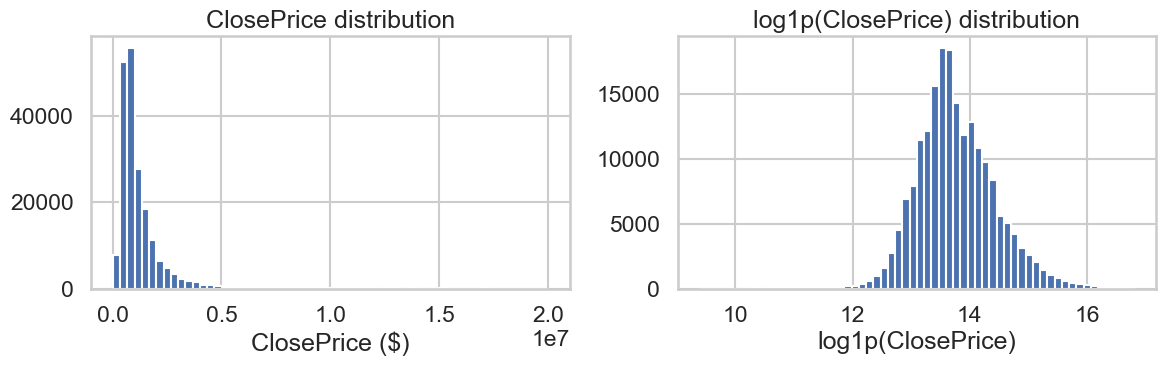

          LivingArea  BedroomsTotal  BathroomsTotalInteger  LotSizeSquareFeet
count  198834.000000  198834.000000          198834.000000       1.988340e+05
mean     2037.295877       3.484932               2.620447       2.202742e+04
std       998.825484       0.953974               1.102270       1.582878e+05
min         0.000000       0.000000               0.000000       0.000000e+00
25%      1383.000000       3.000000               2.000000       5.663000e+03
50%      1812.000000       3.000000               2.000000       7.260000e+03
75%      2432.000000       4.000000               3.000000       1.040000e+04
max     17153.000000      13.000000              14.000000       1.251740e+07


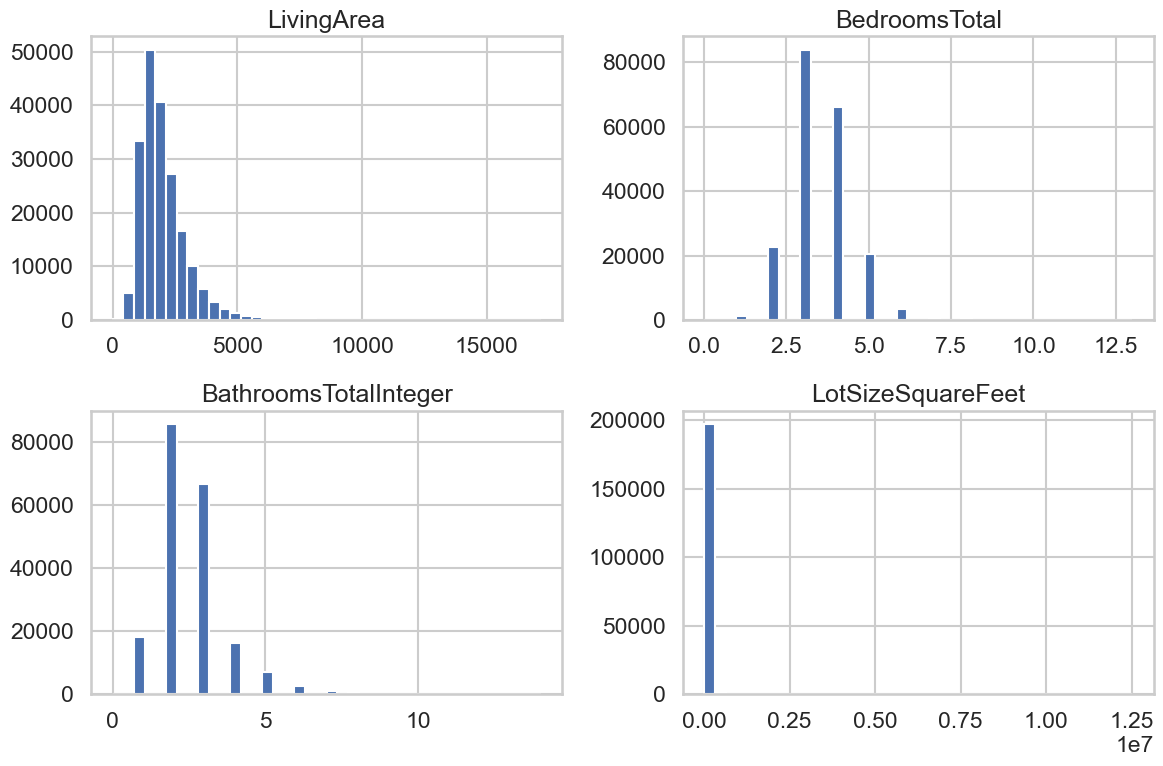

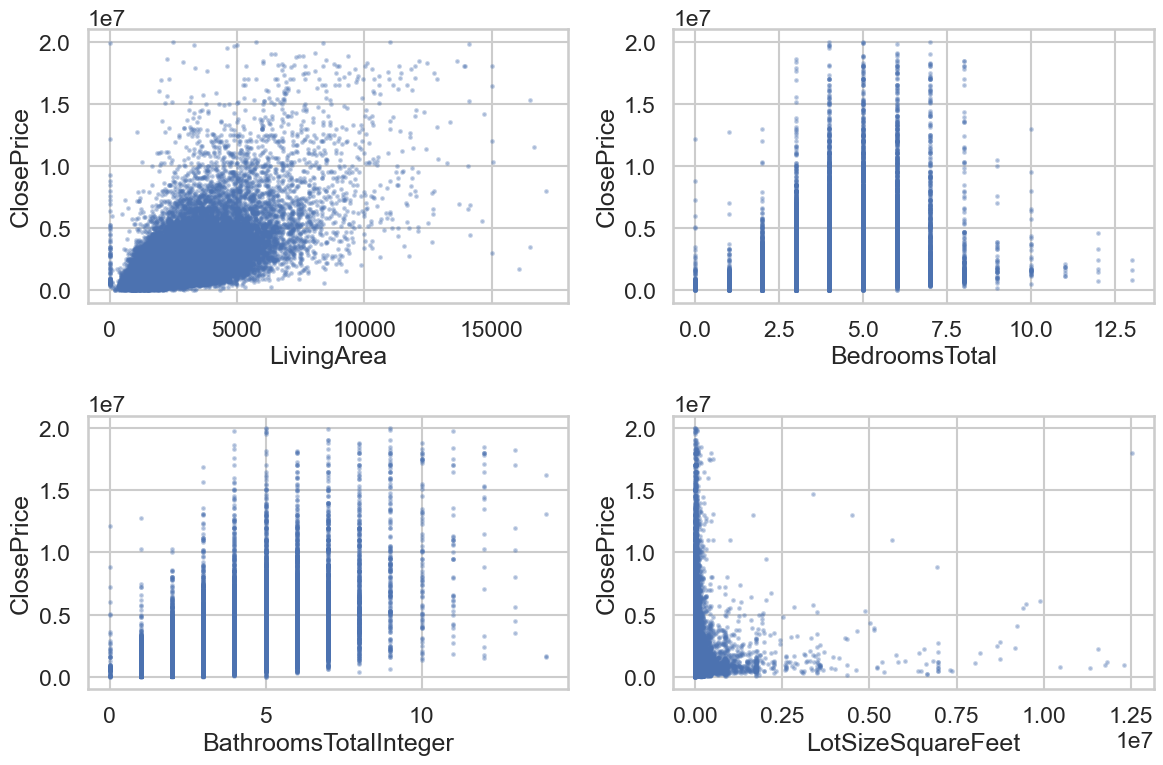

                       LivingArea  BedroomsTotal  BathroomsTotalInteger  \
LivingArea               1.000000       0.662951               0.847592   
BedroomsTotal            0.662951       1.000000               0.656149   
BathroomsTotalInteger    0.847592       0.656149               1.000000   
LotSizeSquareFeet        0.077331       0.014661               0.045971   
ClosePrice               0.627125       0.342949               0.576581   

                       LotSizeSquareFeet  ClosePrice  
LivingArea                      0.077331    0.627125  
BedroomsTotal                   0.014661    0.342949  
BathroomsTotalInteger           0.045971    0.576581  
LotSizeSquareFeet               1.000000    0.037033  
ClosePrice                      0.037033    1.000000  
SourceMonth
2024-11    10505
2024-12    10413
2025-01     7961
2025-02     8666
2025-03    10414
2025-04    11636
2025-05    11552
2025-06    11473
2025-07    11895
2025-08    11227
2025-09    11230
2025-10    11780
202

In [3]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8, 5)

# "raw data" is a sibling folder to "py files" (both live inside "IDX Summer DS")
DATA_DIR = os.path.join("..", "raw data")

# Minimum number of most-recent months to load (per Week 1 task doc: at least 6)
MIN_MONTHS = 6

# --- 1. Load the monthly files ---------------------------------------------
def month_from_filename(path):
    """Extract the YYYYMM tag from a CRMLSSoldYYYYMM.csv filename."""
    stem = os.path.splitext(os.path.basename(path))[0]
    tag = stem.replace("CRMLSSold", "")
    return pd.Period(tag, freq="M")

files = sorted(glob.glob(os.path.join(DATA_DIR, "CRMLSSold*.csv")))
print(f"Found {len(files)} monthly files in: {os.path.abspath(DATA_DIR)}")
assert len(files) >= MIN_MONTHS, f"Need at least {MIN_MONTHS} months of data, found {len(files)}"

frames = []
for f in files:
    df_month = pd.read_csv(f, low_memory=False, encoding="latin1")
    df_month["SourceMonth"] = month_from_filename(f)
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)
print(raw.shape)
print(raw.head())

# --- 2. Restrict to Residential / Single Family Residence -------------------
df = raw[
    (raw["PropertyType"] == "Residential") &
    (raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Rows before filter: {len(raw):,}")
print(f"Rows after filter:  {len(df):,}")
print(df[["PropertyType", "PropertySubType"]].value_counts().head())
# Drop obvious data-entry errors / outliers before analysis
df = df[
    (df["ClosePrice"] > 10000) &              # exclude $0 or near-$0 placeholder rows
    (df["ClosePrice"] < 20_000_000) &         # exclude implausible high-end errors
    (df["BedroomsTotal"] < 15) &
    (df["BathroomsTotalInteger"] < 15) &      # caps unrealistic values like 175 bathrooms
    (df["LivingArea"] < 20000) &
    (df["LotSizeSquareFeet"] < 13_068_000)    # ~300 acres
]
print(f"Rows after outlier filtering: {len(df):,}")

# --- 3. Quick data overview ---------------------------------------------
df.info()

missing = df.isna().mean().sort_values(ascending=False)
print(missing[missing > 0].to_frame("pct_missing"))

# --- 4. Target variable — ClosePrice ----------------------------------------
print(df["ClosePrice"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["ClosePrice"].hist(bins=60, ax=axes[0])
axes[0].set_title("ClosePrice distribution")
axes[0].set_xlabel("ClosePrice ($)")

np.log1p(df["ClosePrice"]).hist(bins=60, ax=axes[1])
axes[1].set_title("log1p(ClosePrice) distribution")
axes[1].set_xlabel("log1p(ClosePrice)")
plt.tight_layout()
plt.savefig("closeprice_distribution.png")
plt.show()

# --- 5. Feature distributions — LivingArea, Bedrooms, Bathrooms, LotSize ----
feature_cols = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
# NOTE: adjust these to the exact column names in Trestle Property MetaData.pdf if they differ
# (e.g. some feeds use "Bedrooms" / "Bathrooms" / "LotSize" directly).

available = [c for c in feature_cols if c in df.columns]
missing_cols = [c for c in feature_cols if c not in df.columns]
if missing_cols:
    print("Not found in this feed, check Trestle Property MetaData.pdf for the correct name:", missing_cols)

print(df[available].describe())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), available):
    df[col].dropna().hist(bins=40, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("feature_distributions.png")
plt.show()

# --- 6. Relationship to ClosePrice ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), available):
    ax.scatter(df[col], df["ClosePrice"], s=4, alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel("ClosePrice")
plt.tight_layout()
plt.savefig("feature_vs_closeprice.png")
plt.show()

print(df[available + ["ClosePrice"]].corr())

# --- 7. Coverage by month ---------------------------------------------------
print(df["SourceMonth"].value_counts().sort_index())

In [4]:
import glob
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 60)

DATA_DIR = os.path.join("..", "raw data")
OUTPUT_CSV = "cleaned_crmls_sold.csv"   

TARGET = "ClosePrice"
NUMERIC_FEATURES = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]

CATEGORICAL_FEATURES = ["City", "PropertySubType"]
DATE_COL = "CloseDate"   

def month_from_filename(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    tag = stem.replace("CRMLSSold", "")
    return pd.Period(tag, freq="M")

files = sorted(glob.glob(os.path.join(DATA_DIR, "CRMLSSold*.csv")))
assert files, f"No CRMLSSold*.csv files found in {os.path.abspath(DATA_DIR)}"

frames = []
for f in files:
    df_month = pd.read_csv(f, low_memory=False, encoding="latin1")
    df_month["SourceMonth"] = month_from_filename(f)
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)

df = raw[
    (raw["PropertyType"] == "Residential") &
    (raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(df.shape)

df = df[
    (df["ClosePrice"] > 10000) &
    (df["ClosePrice"] < 20_000_000) &
    (df["BedroomsTotal"] < 15) &
    (df["BathroomsTotalInteger"] < 15) &
    (df["LivingArea"] < 20000) &
    (df["LotSizeSquareFeet"] < 13_068_000)
]
print(f"Rows after outlier filtering: {len(df):,}")


df = df.dropna(subset=[TARGET])

missing_frac = df.isna().mean()
mostly_empty = missing_frac[missing_frac > 0.6].index.tolist()
print("Dropping mostly-empty columns:", mostly_empty)
df = df.drop(columns=mostly_empty)

for col in NUMERIC_FEATURES:
    if col not in df.columns:
        continue
    if df[col].isna().any():
        df[f"{col}_was_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(df[col].median())

for col in CATEGORICAL_FEATURES:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

print("Remaining nulls in modeling columns:")
cols_to_check = [c for c in (NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]) if c in df.columns]
print(df[cols_to_check].isna().sum())

cat_cols_present = [c for c in CATEGORICAL_FEATURES if c in df.columns]

for col in cat_cols_present:
    print(col, "unique values:", df[col].nunique())

df_encoded = pd.get_dummies(df, columns=cat_cols_present, prefix=cat_cols_present, dtype=int)
print(df_encoded.shape)

numeric_cols_present = [c for c in NUMERIC_FEATURES if c in df_encoded.columns]
print("Numeric columns to scale:", numeric_cols_present)

def build_split(data: pd.DataFrame, x_months: int, month_col: str = "SourceMonth"):
    """Return (train_df, test_df) for a given training-window length X.

    test  = most recent month in `data`
    train = the x_months immediately preceding the test month
    """
    months_available = sorted(data[month_col].unique())
    test_month = months_available[-1]
    train_months = months_available[-(x_months + 1):-1]

    if len(train_months) < x_months:
        raise ValueError(
            f"Only {len(train_months)} prior months available, requested X={x_months}"
        )

    train_df = data[data[month_col].isin(train_months)].copy()
    test_df = data[data[month_col] == test_month].copy()
    return train_df, test_df, train_months, test_month

X = 3
train_df, test_df, train_months, test_month = build_split(df_encoded, X)

print("Train months:", train_months)
print("Test month:  ", test_month)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))

months_available = sorted(df_encoded["SourceMonth"].unique())
max_x = len(months_available) - 1  # leave at least 1 month for test

summary = []
for x in range(1, max_x + 1):
    _, _, tm, test_m = build_split(df_encoded, x)
    summary.append({
        "X": x,
        "train_rows": len(df_encoded[df_encoded['SourceMonth'].isin(tm)]),
        "train_months": f"{tm[0]}..{tm[-1]}"
    })

print(pd.DataFrame(summary))

scaler = StandardScaler()
train_df[numeric_cols_present] = scaler.fit_transform(train_df[numeric_cols_present])
test_df[numeric_cols_present] = scaler.transform(test_df[numeric_cols_present])

train_df["split"] = "train"
test_df["split"] = "test"
final_df = pd.concat([train_df, test_df], ignore_index=True)
print(final_df.head())


final_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(final_df):,} rows to {OUTPUT_CSV}")
print(final_df['split'].value_counts())

(202798, 81)
Rows after outlier filtering: 198,834
Dropping mostly-empty columns: ['WaterfrontYN', 'BasementYN', 'CoListOfficeName', 'CoListAgentFirstName', 'CoListAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'ElementarySchool', 'BuilderName', 'SubdivisionName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'MiddleOrJuniorSchool', 'HighSchool', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict', 'latfilled', 'lonfilled']
Remaining nulls in modeling columns:
LivingArea               0
BedroomsTotal            0
BathroomsTotalInteger    0
LotSizeSquareFeet        0
City                     0
PropertySubType          0
ClosePrice               0
dtype: int64
City unique values: 1050
PropertySubType unique values: 1
(198834, 1105)
Numeric columns to scale: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet'

In [ ]:
# Week 4 — Baseline Model
#Train a Linear Regression baseline on CRMLSSold data, using a fixed date-based
#train/validation/test split. `ListPrice` and `OriginalListPrice` are excluded
#to prevent target leakage.

#Deliverable: `03_baseline_model.ipynb` — trained model + recorded R² results.

In [2]:
import glob
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

pd.set_option('display.max_columns', 60)

DATA_DIR = os.path.join("..", "raw data")
TARGET = "ClosePrice"
DATE_COL = "CloseDate"   

NUMERIC_FEATURES = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]
CATEGORICAL_FEATURES = ["City", "PropertySubType"]


LEAKAGE_COLS = ["ListPrice", "OriginalListPrice"]


TRAIN_START, TRAIN_END = "2024-11-01", "2025-11-30"
VAL_START,   VAL_END   = "2025-12-01", "2026-02-28"
TEST_START,  TEST_END  = "2026-03-01", "2026-05-31"

In [ ]:
#Load all monthly CSVs

In [9]:
def month_from_filename(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    tag = stem.replace("CRMLSSold", "")
    return pd.Period(tag, freq="M")

files = sorted(glob.glob(os.path.join(DATA_DIR, "CRMLSSold*.csv")))
assert files, f"No CRMLSSold*.csv files found in {os.path.abspath(DATA_DIR)}"
print(f"Found {len(files)} monthly files")

frames = []
for f in files:
    df_month = pd.read_csv(f, low_memory=False, encoding="latin1")
    df_month["SourceMonth"] = month_from_filename(f)
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)
print(raw.shape)

Found 19 monthly files
(404490, 81)


In [ ]:
#Filter to Residential / Single Family Residence, and drop outliers

In [11]:
df = raw[
    (raw["PropertyType"] == "Residential") &
    (raw["PropertySubType"] == "SingleFamilyResidence")
].copy()
print(f"Rows after Residential/SingleFamilyResidence filter: {len(df):,}")

df = df[
    (df["ClosePrice"] > 10000) &
    (df["ClosePrice"] < 20_000_000) &
    (df["BedroomsTotal"] < 15) &
    (df["BathroomsTotalInteger"] < 15) &
    (df["LivingArea"] < 20000) &
    (df["LotSizeSquareFeet"] < 13_068_000)   # ~300 acres
]
print(f"Rows after outlier filtering: {len(df):,}")

Rows after Residential/SingleFamilyResidence filter: 202,798
Rows after outlier filtering: 198,834


In [ ]:
#Drop leakage columns

In [13]:
present_leakage_cols = [c for c in LEAKAGE_COLS if c in df.columns]
print("Dropping leakage columns:", present_leakage_cols)
df = df.drop(columns=present_leakage_cols)

Dropping leakage columns: ['ListPrice', 'OriginalListPrice']


In [ ]:
#Build the fixed train / validation / test split
#Train: Nov 2024 – Nov 2025
#Validation: Dec 2025 – Feb 2026
#Test: Mar 2026 – May 2026

In [15]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL])

train_df = df[(df[DATE_COL] >= TRAIN_START) & (df[DATE_COL] <= TRAIN_END)].copy()
val_df   = df[(df[DATE_COL] >= VAL_START)   & (df[DATE_COL] <= VAL_END)].copy()
test_df  = df[(df[DATE_COL] >= TEST_START)  & (df[DATE_COL] <= TEST_END)].copy()

print(f"Train rows ({TRAIN_START} to {TRAIN_END}): {len(train_df):,}")
print(f"Val rows   ({VAL_START} to {VAL_END}):     {len(val_df):,}")
print(f"Test rows  ({TEST_START} to {TEST_END}):   {len(test_df):,}")

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert len(split) > 0, f"{name} split is empty — check date coverage in raw data"

Train rows (2024-11-01 to 2025-11-30): 138,317
Val rows   (2025-12-01 to 2026-02-28):     25,960
Test rows  (2026-03-01 to 2026-05-31):   34,557


In [ ]:
#Handle missing values
#Medians and "was missing" flags are fit on **train only**, then applied to
#validation/test

In [17]:
def clean_missing(data, medians=None, fit=False):
    data = data.copy()
    if fit:
        medians = {}
    for col in NUMERIC_FEATURES:
        if col not in data.columns:
            continue
        if fit:
            medians[col] = data[col].median()
        data[f"{col}_was_missing"] = data[col].isna().astype(int)
        data[col] = data[col].fillna(medians[col])
    for col in CATEGORICAL_FEATURES:
        if col in data.columns:
            data[col] = data[col].fillna("Unknown")
    return data, medians

train_df, medians = clean_missing(train_df, fit=True)
val_df, _  = clean_missing(val_df, medians=medians, fit=False)
test_df, _ = clean_missing(test_df, medians=medians, fit=False)

print("Missing-value medians (fit on train):", medians)

Missing-value medians (fit on train): {'LivingArea': np.float64(1807.0), 'BedroomsTotal': np.float64(3.0), 'BathroomsTotalInteger': np.float64(2.0), 'LotSizeSquareFeet': np.float64(7260.0)}


In [ ]:
#Encode categorical fields
#Categories are one-hot encoded on train, then val/test are aligned to the
#same columns (any category unseen in train gets filled with 0)

In [19]:
cat_cols_present = [c for c in CATEGORICAL_FEATURES if c in train_df.columns]

train_enc = pd.get_dummies(train_df, columns=cat_cols_present, prefix=cat_cols_present, dtype=int)
val_enc   = pd.get_dummies(val_df,   columns=cat_cols_present, prefix=cat_cols_present, dtype=int)
test_enc  = pd.get_dummies(test_df,  columns=cat_cols_present, prefix=cat_cols_present, dtype=int)

val_enc  = val_enc.reindex(columns=train_enc.columns, fill_value=0)
test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

print(train_enc.shape, val_enc.shape, test_enc.shape)

(138317, 1067) (25960, 1067) (34557, 1067)


In [ ]:
#Build feature matrices and scale numeric features

In [ ]:

encoded_cat_cols = [c for c in train_enc.columns
                     if any(c.startswith(f"{cat}_") for cat in cat_cols_present)]

feature_cols = NUMERIC_FEATURES + [c for c in train_enc.columns if c.endswith("_was_missing")] + encoded_cat_cols
feature_cols = [c for c in feature_cols if c in train_enc.columns]  # safety filter

X_train, y_train = train_enc[feature_cols], train_enc[TARGET]
X_val,   y_val   = val_enc[feature_cols],   val_enc[TARGET]
X_test,  y_test  = test_enc[feature_cols],  test_enc[TARGET]

numeric_cols_present = [c for c in NUMERIC_FEATURES if c in X_train.columns]
scaler = StandardScaler()
X_train[numeric_cols_present] = scaler.fit_transform(X_train[numeric_cols_present])
X_val[numeric_cols_present]   = scaler.transform(X_val[numeric_cols_present])
X_test[numeric_cols_present]  = scaler.transform(X_test[numeric_cols_present])

print(f"Feature count: {len(feature_cols)}")
print(feature_cols[:20], "..." if len(feature_cols) > 20 else "")

Feature count: 994
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'LivingArea_was_missing', 'BedroomsTotal_was_missing', 'BathroomsTotalInteger_was_missing', 'LotSizeSquareFeet_was_missing', 'City_29 Palms', 'City_Acton', 'City_Adelanto', 'City_Adin', 'City_Agoura', 'City_Agoura Hills', 'City_Agua Dulce', 'City_Aguanga', 'City_Ahwahnee', 'City_Alameda', 'City_Alamo', 'City_Albany'] ...


C:\Users\alexa\AppData\Local\Temp\ipykernel_15812\1398515956.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[numeric_cols_present] = scaler.fit_transform(X_train[numeric_cols_present])
C:\Users\alexa\AppData\Local\Temp\ipykernel_15812\1398515956.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[numeric_cols_present]   = scaler.transform(X_val[numeric_cols_present])
C:\Users\alexa\AppData\Local\Temp\ipykernel_15812\1398515956.py:18: SettingWithCopyWarning: 
A value is trying to be set o

In [ ]:
#Train baseline Linear Regression

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [ ]:
#Evaluate with R² on train, validation, and test sets

In [27]:
train_r2 = r2_score(y_train, model.predict(X_train))
val_r2   = r2_score(y_val,   model.predict(X_val))
test_r2  = r2_score(y_test,  model.predict(X_test))

print(f"Train R²:      {train_r2:.4f}")
print(f"Validation R²: {val_r2:.4f}")
print(f"Test R²:       {test_r2:.4f}")

Train R²:      0.7396
Validation R²: 0.7171
Test R²:       0.7314


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_split(y_true, y_pred, split_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {
        "split": split_name,
        "n_rows": len(y_true),
        "actual_mean_price": y_true.mean(),
        "predicted_mean_price": y_pred.mean(),
        "rmse": rmse,
        "mae": mae,
        "mape_pct": mape,
        "r2": r2,
    }

train_pred = model.predict(X_train)
val_pred   = model.predict(X_val)
test_pred  = model.predict(X_test)

price_results = pd.DataFrame([
    evaluate_split(y_train, train_pred, "train"),
    evaluate_split(y_val,   val_pred,   "validation"),
    evaluate_split(y_test,  test_pred,  "test"),
])

price_results = price_results.round(2)
price_results.to_csv("baseline_price_error_by_split.csv", index=False)
print("Saved to baseline_price_error_by_split.csv")
price_results

Saved to baseline_price_error_by_split.csv


,split,n_rows,actual_mean_price,predicted_mean_price,rmse,mae,mape_pct,r2
0,train,138317,1234145.74,1234145.74,607363.50,318242.03,31.53,0.74
1,validation,25960,1198323.28,1205993.12,651641.97,330165.47,33.43,0.72
2,test,34557,1274706.01,1256016.93,647451.00,332953.57,32.94,0.73


: 

In [ ]:
#baseline results

In [29]:
results = pd.DataFrame([{
    "model": "LinearRegression",
    "features_used": len(feature_cols),
    "excluded_features": ", ".join(present_leakage_cols),
    "train_rows": len(X_train),
    "val_rows": len(X_val),
    "test_rows": len(X_test),
    "train_r2": train_r2,
    "val_r2": val_r2,
    "test_r2": test_r2,
}])
results.to_csv("baseline_model_results.csv", index=False)
print("Saved baseline results to baseline_model_results.csv")
results

Saved baseline results to baseline_model_results.csv


,model,features_used,excluded_features,train_rows,val_rows,test_rows,train_r2,val_r2,test_r2
0,LinearRegression,994,"ListPrice, OriginalListPrice",138317,25960,34557,0.739581,0.717064,0.731377


In [21]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

DATA_DIR = os.path.join("..", "raw data")
TARGET = "ClosePrice"
DATE_COL = "CloseDate"

# --- Feature set: City restored + new property characteristics added ---
NUMERIC_FEATURES = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet",
    "YearBuilt", "GarageSpaces", "Latitude", "Longitude"
]

CATEGORICAL_FEATURES = [
    "City", "PropertySubType", "CountyOrParish", "Stories",
    "NewConstructionYN", "PoolPrivateYN", "ViewYN", "AttachedGarageYN"
]

# Fields that must NEVER be used as model features — they leak the target
LEAKAGE_COLS = [
    "ListPrice",
    "OriginalListPrice",
    "ClosePricePerSquareFoot",
    "PricePerSquareFoot",
    "SoldPrice",
]

# --- Fixed split per team decision ---
TRAIN_MONTHS = pd.period_range("2025-02", "2026-01", freq="M")  # 12 months
VAL_MONTHS   = pd.period_range("2026-02", "2026-04", freq="M")  # 3 months
TEST_MONTHS  = pd.period_range("2026-05", "2026-05", freq="M")  # 1 month (most recent)

print("Train months:", list(TRAIN_MONTHS))
print("Val months:  ", list(VAL_MONTHS))
print("Test months: ", list(TEST_MONTHS))

Train months: [Period('2025-02', 'M'), Period('2025-03', 'M'), Period('2025-04', 'M'), Period('2025-05', 'M'), Period('2025-06', 'M'), Period('2025-07', 'M'), Period('2025-08', 'M'), Period('2025-09', 'M'), Period('2025-10', 'M'), Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M')]
Val months:   [Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M')]
Test months:  [Period('2026-05', 'M')]


Load all monthly CSVs and filter to Residential / Single Family Residence

In [22]:
def month_from_filename(path):
    stem = os.path.splitext(os.path.basename(path))[0]
    tag = stem.replace("CRMLSSold", "")
    return pd.Period(tag, freq="M")

files = sorted(glob.glob(os.path.join(DATA_DIR, "CRMLSSold*.csv")))
assert files, f"No CRMLSSold*.csv files found in {os.path.abspath(DATA_DIR)}"

frames = []
for f in files:
    df_month = pd.read_csv(f, low_memory=False, encoding="latin1")
    df_month["SourceMonth"] = month_from_filename(f)
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)

base_df = raw[
    (raw["PropertyType"] == "Residential") &
    (raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

base_df[DATE_COL] = pd.to_datetime(base_df[DATE_COL], errors="coerce")
base_df = base_df.dropna(subset=[DATE_COL])
base_df["CloseMonth"] = base_df[DATE_COL].dt.to_period("M")

present_leakage_cols = [c for c in LEAKAGE_COLS if c in base_df.columns]
base_df = base_df.drop(columns=present_leakage_cols)

print(f"Rows after Residential/SFR filter: {len(base_df):,}")
print("Dropped leakage columns:", present_leakage_cols)

Rows after Residential/SFR filter: 202,798
Dropped leakage columns: ['ListPrice', 'OriginalListPrice']


In [23]:
import re

price_related = [c for c in base_df.columns
                  if re.search(r"price|list", c, re.IGNORECASE)]

print("All price/list-related columns still present in the data:")
for c in price_related:
    print(f"  {c}")

All price/list-related columns still present in the data:
  ListAgentAOR
  ListingKey
  ListAgentEmail
  ClosePrice
  ListAgentFirstName
  ListAgentLastName
  ListOfficeName
  CoListOfficeName
  ListAgentFullName
  CoListAgentFirstName
  CoListAgentLastName
  ListingKeyNumeric
  ListingId
  ListingContractDate


In [24]:
def remove_outliers(df):
    return df[
        (df["ClosePrice"] > 10000) &
        (df["ClosePrice"] < 20_000_000) &
        (df["BedroomsTotal"] < 15) &
        (df["BathroomsTotalInteger"] < 15) &
        (df["LivingArea"] < 20000) &
        (df["LotSizeSquareFeet"] < 13_068_000)
    ].copy()

df_with_outliers = base_df.copy()
df_no_outliers = remove_outliers(base_df)

print(f"Rows WITH outliers:    {len(df_with_outliers):,}")
print(f"Rows WITHOUT outliers: {len(df_no_outliers):,}")
print(f"Rows removed:          {len(df_with_outliers) - len(df_no_outliers):,} "
      f"({(1 - len(df_no_outliers)/len(df_with_outliers))*100:.2f}%)")

Rows WITH outliers:    202,798
Rows WITHOUT outliers: 198,834
Rows removed:          3,964 (1.95%)


In [25]:
def prepare_data(df):
    train_df = df[df["CloseMonth"].isin(TRAIN_MONTHS)].copy()
    val_df   = df[df["CloseMonth"].isin(VAL_MONTHS)].copy()
    test_df  = df[df["CloseMonth"].isin(TEST_MONTHS)].copy()

    for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
        assert len(split) > 0, f"{name} split is empty — check date coverage in raw data"

    medians = {}
    for split, fit in [(train_df, True), (val_df, False), (test_df, False)]:
        for col in NUMERIC_FEATURES:
            if col not in split.columns:
                continue
            if fit:
                medians[col] = split[col].median()
            split[f"{col}_was_missing"] = split[col].isna().astype(int)
            split[col] = split[col].fillna(medians[col])
        for col in CATEGORICAL_FEATURES:
            if col in split.columns:
                split[col] = split[col].fillna("Unknown")

    cat_cols_present = [c for c in CATEGORICAL_FEATURES if c in train_df.columns]
    train_enc = pd.get_dummies(train_df, columns=cat_cols_present, prefix=cat_cols_present, dtype=int)
    val_enc   = pd.get_dummies(val_df,   columns=cat_cols_present, prefix=cat_cols_present, dtype=int)
    test_enc  = pd.get_dummies(test_df,  columns=cat_cols_present, prefix=cat_cols_present, dtype=int)
    val_enc  = val_enc.reindex(columns=train_enc.columns, fill_value=0)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

    encoded_cat_cols = [c for c in train_enc.columns
                         if any(c.startswith(f"{cat}_") for cat in cat_cols_present)]
    missing_flag_cols = [c for c in train_enc.columns if c.endswith("_was_missing")]
    feature_cols = [c for c in (NUMERIC_FEATURES + missing_flag_cols + encoded_cat_cols)
                    if c in train_enc.columns]

    X_train, y_train = train_enc[feature_cols].copy(), train_enc[TARGET]
    X_val,   y_val   = val_enc[feature_cols].copy(),   val_enc[TARGET]
    X_test,  y_test  = test_enc[feature_cols].copy(),  test_enc[TARGET]

    numeric_cols_present = [c for c in NUMERIC_FEATURES if c in X_train.columns]
    scaler = StandardScaler()
    X_train[numeric_cols_present] = scaler.fit_transform(X_train[numeric_cols_present])
    X_val[numeric_cols_present]   = scaler.transform(X_val[numeric_cols_present])
    X_test[numeric_cols_present]  = scaler.transform(X_test[numeric_cols_present])

    return X_train, y_train, X_val, y_val, X_test, y_test, feature_cols

data_with_outliers = prepare_data(df_with_outliers)
data_no_outliers   = prepare_data(df_no_outliers)
print("Both datasets prepared.")

Both datasets prepared.


linear regression with outliers

In [26]:

X_train_wo, y_train_wo, X_val_wo, y_val_wo, X_test_wo, y_test_wo, feature_cols_wo = data_with_outliers

model_with_outliers = LinearRegression()
model_with_outliers.fit(X_train_wo, y_train_wo)

train_r2_wo = r2_score(y_train_wo, model_with_outliers.predict(X_train_wo))
val_r2_wo   = r2_score(y_val_wo,   model_with_outliers.predict(X_val_wo))
test_r2_wo  = r2_score(y_test_wo,  model_with_outliers.predict(X_test_wo))

print("--- WITH OUTLIERS ---")
print(f"Features used: {len(feature_cols_wo)}")
print(f"Train R²:      {train_r2_wo:.4f}")
print(f"Validation R²: {val_r2_wo:.4f}")
print(f"Test R²:       {test_r2_wo:.4f}")

--- WITH OUTLIERS ---
Features used: 1070
Train R²:      0.1376
Validation R²: 0.0151
Test R²:       0.4223


Without outliers

In [27]:

X_train_no, y_train_no, X_val_no, y_val_no, X_test_no, y_test_no, feature_cols_no = data_no_outliers

model_no_outliers = LinearRegression()
model_no_outliers.fit(X_train_no, y_train_no)

train_r2_no = r2_score(y_train_no, model_no_outliers.predict(X_train_no))
val_r2_no   = r2_score(y_val_no,   model_no_outliers.predict(X_val_no))
test_r2_no  = r2_score(y_test_no,  model_no_outliers.predict(X_test_no))

print("--- WITHOUT OUTLIERS ---")
print(f"Features used: {len(feature_cols_no)}")
print(f"Train R²:      {train_r2_no:.4f}")
print(f"Validation R²: {val_r2_no:.4f}")
print(f"Test R²:       {test_r2_no:.4f}")

--- WITHOUT OUTLIERS ---
Features used: 1067
Train R²:      0.7470
Validation R²: 0.7321
Test R²:       0.7662


In [29]:
def add_city_target_encoding(train_df, val_df, test_df, target_col=TARGET,
                               city_col="City", smoothing=10):
    """
    Replace City with a smoothed target-encoded numeric column.
    Fit (compute city means) on train only; apply the same mapping to val/test.
    Cities unseen in train fall back to the global train mean.
    """
    global_mean = train_df[target_col].mean()

    city_stats = train_df.groupby(city_col)[target_col].agg(["mean", "count"])

    # Smoothing: blend each city's mean with the global mean, weighted by
    # how many sales that city has — cities with few sales lean more
    # heavily toward the global average, preventing overfit on rare cities.
    city_stats["smoothed_mean"] = (
        (city_stats["mean"] * city_stats["count"]) + (global_mean * smoothing)
    ) / (city_stats["count"] + smoothing)

    city_encoding_map = city_stats["smoothed_mean"].to_dict()

    for df in (train_df, val_df, test_df):
        df["City_TargetEnc"] = df[city_col].map(city_encoding_map).fillna(global_mean)

    return train_df, val_df, test_df, city_encoding_map

print("Function defined.")

Function defined.


In [30]:
def prepare_data_target_enc(df):
    train_df = df[df["CloseMonth"].isin(TRAIN_MONTHS)].copy()
    val_df   = df[df["CloseMonth"].isin(VAL_MONTHS)].copy()
    test_df  = df[df["CloseMonth"].isin(TEST_MONTHS)].copy()

    for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
        assert len(split) > 0, f"{name} split is empty — check date coverage in raw data"

    # Target-encode City (fit on train only)
    train_df, val_df, test_df, city_map = add_city_target_encoding(train_df, val_df, test_df)

    # Categorical features WITHOUT City (it's now numeric via target encoding)
    cat_cols = [c for c in CATEGORICAL_FEATURES if c != "City"]

    # Missing values — fit medians on train only
    medians = {}
    numeric_features_with_city_enc = NUMERIC_FEATURES + ["City_TargetEnc"]
    for split, fit in [(train_df, True), (val_df, False), (test_df, False)]:
        for col in numeric_features_with_city_enc:
            if col not in split.columns:
                continue
            if fit:
                medians[col] = split[col].median()
            split[f"{col}_was_missing"] = split[col].isna().astype(int)
            split[col] = split[col].fillna(medians[col])
        for col in cat_cols:
            if col in split.columns:
                split[col] = split[col].fillna("Unknown")

    # Encode remaining categoricals (no City here anymore)
    train_enc = pd.get_dummies(train_df, columns=cat_cols, prefix=cat_cols, dtype=int)
    val_enc   = pd.get_dummies(val_df,   columns=cat_cols, prefix=cat_cols, dtype=int)
    test_enc  = pd.get_dummies(test_df,  columns=cat_cols, prefix=cat_cols, dtype=int)
    val_enc  = val_enc.reindex(columns=train_enc.columns, fill_value=0)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

    # Whitelist feature columns
    encoded_cat_cols = [c for c in train_enc.columns
                         if any(c.startswith(f"{cat}_") for cat in cat_cols)]
    missing_flag_cols = [c for c in train_enc.columns if c.endswith("_was_missing")]
    feature_cols = [c for c in (numeric_features_with_city_enc + missing_flag_cols + encoded_cat_cols)
                    if c in train_enc.columns]

    X_train, y_train = train_enc[feature_cols].copy(), train_enc[TARGET]
    X_val,   y_val   = val_enc[feature_cols].copy(),   val_enc[TARGET]
    X_test,  y_test  = test_enc[feature_cols].copy(),  test_enc[TARGET]

    # Scale numeric features (now includes City_TargetEnc)
    numeric_cols_present = [c for c in numeric_features_with_city_enc if c in X_train.columns]
    scaler = StandardScaler()
    X_train[numeric_cols_present] = scaler.fit_transform(X_train[numeric_cols_present])
    X_val[numeric_cols_present]   = scaler.transform(X_val[numeric_cols_present])
    X_test[numeric_cols_present]  = scaler.transform(X_test[numeric_cols_present])

    return X_train, y_train, X_val, y_val, X_test, y_test, feature_cols, city_map

data_target_enc = prepare_data_target_enc(df_no_outliers)
X_train_te, y_train_te, X_val_te, y_val_te, X_test_te, y_test_te, feature_cols_te, city_map = data_target_enc
print(f"Feature count (City target-encoded): {len(feature_cols_te)}")

Feature count (City target-encoded): 93


In [31]:
model_target_enc = LinearRegression()
model_target_enc.fit(X_train_te, y_train_te)

train_r2_te = r2_score(y_train_te, model_target_enc.predict(X_train_te))
val_r2_te   = r2_score(y_val_te,   model_target_enc.predict(X_val_te))
test_r2_te  = r2_score(y_test_te,  model_target_enc.predict(X_test_te))

print("--- LINEAR REGRESSION (City target-encoded) ---")
print(f"Features used:  {len(feature_cols_te)}")
print(f"Train R²:       {train_r2_te:.4f}")
print(f"Validation R²:  {val_r2_te:.4f}")
print(f"Test R²:        {test_r2_te:.4f}")

--- LINEAR REGRESSION (City target-encoded) ---
Features used:  93
Train R²:       0.7235
Validation R²:  0.7104
Test R²:        0.7420


Residual plots

Using the **no-outliers** dataset for these on the **test set** specifically, since that's the
most realistic simulation of production performance.

R² matrix (feature vs feature):


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,GarageSpaces,Latitude,Longitude,ClosePrice
LivingArea,1.000,0.440,0.718,0.006,0.134,0.019,0.004,0.001,0.393
BedroomsTotal,0.440,1.000,0.431,0.000,0.079,0.011,0.002,0.000,0.118
BathroomsTotalInteger,0.718,0.431,1.000,0.002,0.156,0.014,0.007,0.001,0.332
LotSizeSquareFeet,0.006,0.000,0.002,1.000,0.001,0.000,0.002,0.000,0.001
YearBuilt,0.134,0.079,0.156,0.001,1.000,0.013,0.005,0.012,0.000
GarageSpaces,0.019,0.011,0.014,0.000,0.013,1.000,0.001,0.000,0.004
Latitude,0.004,0.002,0.007,0.002,0.005,0.001,1.000,0.375,0.000
Longitude,0.001,0.000,0.001,0.000,0.012,0.000,0.375,1.000,0.005
ClosePrice,0.393,0.118,0.332,0.001,0.000,0.004,0.000,0.005,1.000


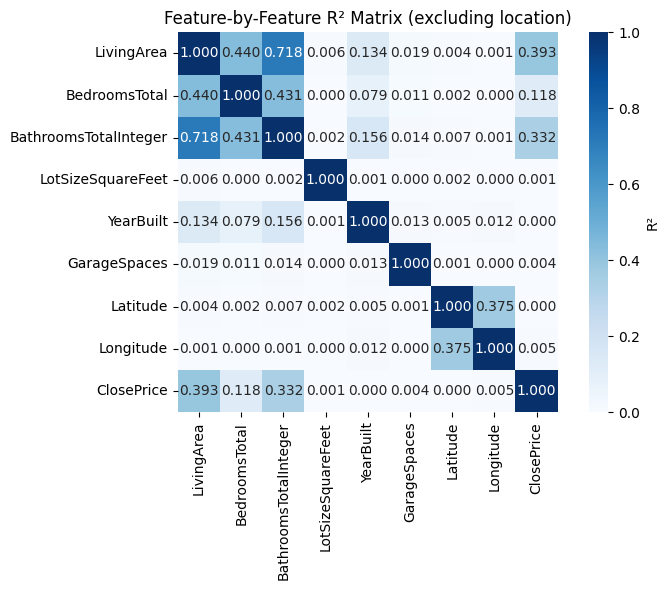

Saved to feature_r2_matrix.csv


In [28]:
import seaborn as sns

numeric_cols = NUMERIC_FEATURES + [TARGET]
corr_df = df_no_outliers[numeric_cols].copy()

corr_matrix = corr_df.corr()

r2_matrix = corr_matrix ** 2

print("R² matrix (feature vs feature):")
display(r2_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(r2_matrix, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "R²"})
plt.title("Feature-by-Feature R² Matrix (excluding location)")
plt.tight_layout()
plt.savefig("feature_r2_matrix.png")
plt.show()

r2_matrix.to_csv("feature_r2_matrix.csv")
print("Saved to feature_r2_matrix.csv")

## Decision Tree & Random Forest — vs. Linear Regression baseline

All models trained using target-encoded City (one numeric column per
city, smoothed toward the global mean) rather than one-hot encoding —
keeps the feature count manageable (~93 features) while retaining most
of City's predictive signal, based on our earlier comparison.

In [32]:
dt_model_te = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
dt_model_te.fit(X_train_te, y_train_te)

dt_train_r2_te = r2_score(y_train_te, dt_model_te.predict(X_train_te))
dt_val_r2_te   = r2_score(y_val_te,   dt_model_te.predict(X_val_te))
dt_test_r2_te  = r2_score(y_test_te,  dt_model_te.predict(X_test_te))

print("--- DECISION TREE (target-encoded City) ---")
print(f"Features used: {len(feature_cols_te)}")
print(f"Train R²:      {dt_train_r2_te:.4f}")
print(f"Validation R²: {dt_val_r2_te:.4f}")
print(f"Test R²:       {dt_test_r2_te:.4f}")

--- DECISION TREE (target-encoded City) ---
Features used: 93
Train R²:      0.8693
Validation R²: 0.7532
Test R²:       0.7831


In [33]:
rf_model_te = RandomForestRegressor(
    n_estimators=200, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE
)
rf_model_te.fit(X_train_te, y_train_te)

rf_train_r2_te = r2_score(y_train_te, rf_model_te.predict(X_train_te))
rf_val_r2_te   = r2_score(y_val_te,   rf_model_te.predict(X_val_te))
rf_test_r2_te  = r2_score(y_test_te,  rf_model_te.predict(X_test_te))

print("--- RANDOM FOREST (target-encoded City) ---")
print(f"Features used: {len(feature_cols_te)}")
print(f"Train R²:      {rf_train_r2_te:.4f}")
print(f"Validation R²: {rf_val_r2_te:.4f}")
print(f"Test R²:       {rf_test_r2_te:.4f}")

--- RANDOM FOREST (target-encoded City) ---
Features used: 93
Train R²:      0.9581
Validation R²: 0.8362
Test R²:       0.8534


In [34]:
comparison = pd.DataFrame([
    {"model": "LinearRegression", "test_r2": test_r2_te,    "n_features": len(feature_cols_te)},
    {"model": "DecisionTree",     "test_r2": dt_test_r2_te, "n_features": len(feature_cols_te)},
    {"model": "RandomForest",     "test_r2": rf_test_r2_te, "n_features": len(feature_cols_te)},
])
comparison = comparison.sort_values("test_r2", ascending=False).reset_index(drop=True)
comparison.to_csv("week5_model_comparison_results.csv", index=False)
comparison

,model,test_r2,n_features
0,RandomForest,0.853373,93
1,DecisionTree,0.783099,93
2,LinearRegression,0.741998,93


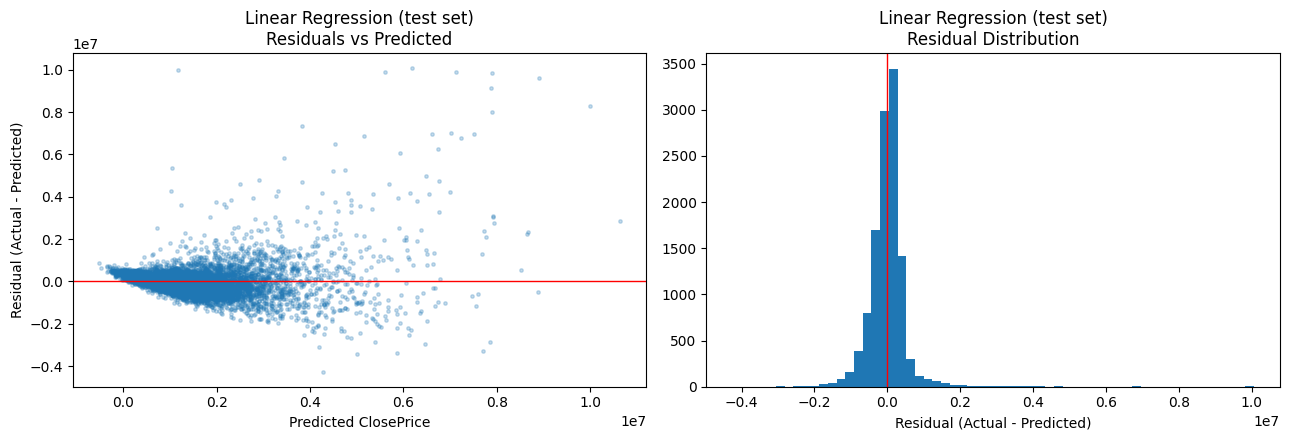

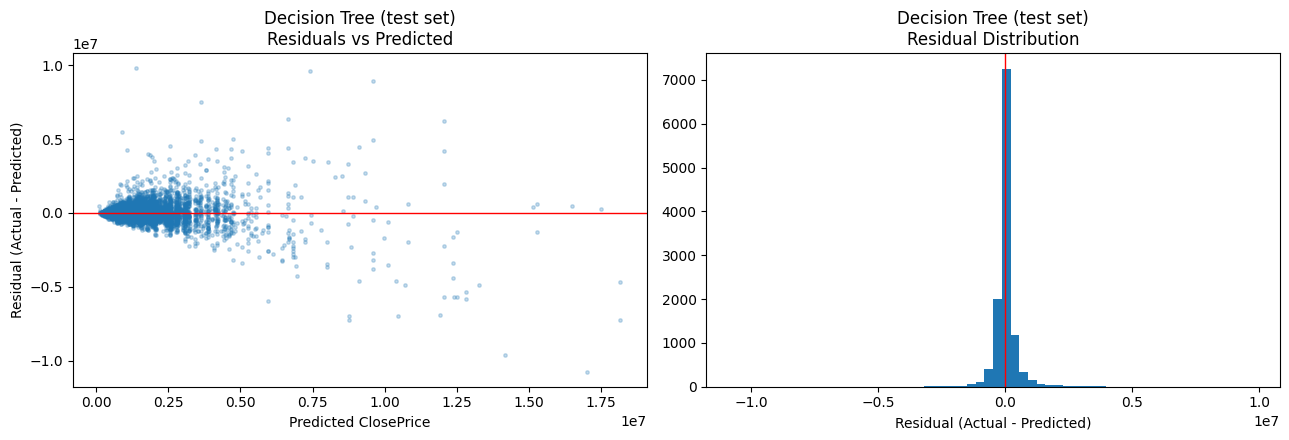

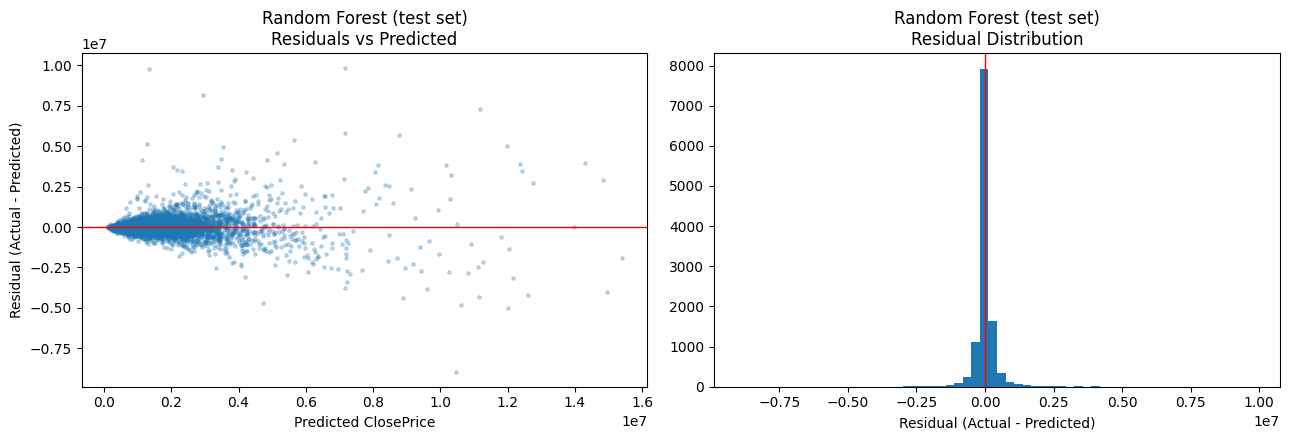

In [35]:
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(y_pred, residuals, s=6, alpha=0.25)
    axes[0].axhline(0, color="red", linewidth=1)
    axes[0].set_xlabel("Predicted ClosePrice")
    axes[0].set_ylabel("Residual (Actual - Predicted)")
    axes[0].set_title(f"{title}\nResiduals vs Predicted")
    axes[1].hist(residuals, bins=60)
    axes[1].axvline(0, color="red", linewidth=1)
    axes[1].set_xlabel("Residual (Actual - Predicted)")
    axes[1].set_title(f"{title}\nResidual Distribution")
    plt.tight_layout()
    plt.show()

plot_residuals(y_test_te, model_target_enc.predict(X_test_te), "Linear Regression (test set)")
plot_residuals(y_test_te, dt_model_te.predict(X_test_te), "Decision Tree (test set)")
plot_residuals(y_test_te, rf_model_te.predict(X_test_te), "Random Forest (test set)")

In [36]:
print(f"Decision Tree  — Train R²: {dt_train_r2_te:.4f} | Test R²: {dt_test_r2_te:.4f}")
print(f"Random Forest  — Train R²: {rf_train_r2_te:.4f} | Test R²: {rf_test_r2_te:.4f}")

Decision Tree  — Train R²: 0.8693 | Test R²: 0.7831
Random Forest  — Train R²: 0.9581 | Test R²: 0.8534


In [37]:
# Try a shallower, more regularized Random Forest
rf_model_regularized = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,            # reduced from 15
    min_samples_leaf=5,      # requires at least 5 samples per leaf — prevents tiny, noisy leaves
    max_features="sqrt",     # limits features considered per split — reduces overfitting
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_model_regularized.fit(X_train_te, y_train_te)

rf_reg_train_r2 = r2_score(y_train_te, rf_model_regularized.predict(X_train_te))
rf_reg_test_r2  = r2_score(y_test_te,  rf_model_regularized.predict(X_test_te))

print("--- RANDOM FOREST (regularized) ---")
print(f"Train R²: {rf_reg_train_r2:.4f}")
print(f"Test R²:  {rf_reg_test_r2:.4f}")
print(f"Gap:      {rf_reg_train_r2 - rf_reg_test_r2:.4f}")

--- RANDOM FOREST (regularized) ---
Train R²: 0.7664
Test R²:  0.7498
Gap:      0.0166


In [38]:
depth_options = [10, 12, 15, 18, 20, None]  # None = fully unrestricted depth
sweep_results = []

for depth in depth_options:
    rf_temp = RandomForestRegressor(
        n_estimators=200, max_depth=depth, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    rf_temp.fit(X_train_te, y_train_te)
    train_r2 = r2_score(y_train_te, rf_temp.predict(X_train_te))
    test_r2 = r2_score(y_test_te, rf_temp.predict(X_test_te))
    sweep_results.append({
        "max_depth": depth, "train_r2": train_r2, "test_r2": test_r2,
        "gap": train_r2 - test_r2
    })

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,max_depth,train_r2,test_r2,gap
0,10.0,0.887796,0.839026,0.048771
1,12.0,0.918937,0.850391,0.068546
2,15.0,0.945393,0.859590,0.085803
3,18.0,0.956478,0.862359,0.094119
4,20.0,0.959767,0.862727,0.097039
5,NaN,0.962554,0.863560,0.098994


In [39]:
rf_model_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_model_final.fit(X_train_te, y_train_te)

train_r2_final = r2_score(y_train_te, rf_model_final.predict(X_train_te))
test_r2_final  = r2_score(y_test_te,  rf_model_final.predict(X_test_te))
print(f"Final Random Forest — Train R²: {train_r2_final:.4f} | Test R²: {test_r2_final:.4f}")

Final Random Forest — Train R²: 0.9454 | Test R²: 0.8596


# Week 6 — Feature Engineering

New features added:
1. `BedBathRatio` — bedrooms / bathrooms
2. `PropertyAgeYears` — derived from YearBuilt
3. `LivingArea_to_LotSize` — building density ratio
4. `DistanceToCoastMiles` — proximity to CA coastline
5. `SchoolDistrictName` — spatial join against CA School District Areas 2024-25
   (https://data.ca.gov/dataset/california-school-district-areas-2024-25)

All models are re-trained on the expanded feature set and compared
against the Week 5 results.

**Deliverable:** updated notebook + old vs. new feature comparison table.

In [41]:
import numpy as np

# Work off the outlier-filtered dataframe used in Week 5
df_fe = df_no_outliers.copy()

# 1. Bed/Bath ratio
df_fe["BedBathRatio"] = df_fe["BedroomsTotal"] / df_fe["BathroomsTotalInteger"].replace(0, np.nan)

# 2. Property age in years (relative to close date, not "today" — avoids the
#    age constantly shifting depending on when you happen to run the notebook)
df_fe["PropertyAgeYears"] = df_fe[DATE_COL].dt.year - df_fe["YearBuilt"]
df_fe.loc[df_fe["PropertyAgeYears"] < 0, "PropertyAgeYears"] = np.nan  # guard against bad YearBuilt data

# 3. Living area to lot size ratio (building density)
df_fe["LivingArea_to_LotSize"] = df_fe["LivingArea"] / df_fe["LotSizeSquareFeet"].replace(0, np.nan)

print(df_fe[["BedBathRatio", "PropertyAgeYears", "LivingArea_to_LotSize"]].describe())

        BedBathRatio  PropertyAgeYears  LivingArea_to_LotSize
count  198747.000000     198693.000000          198732.000000
mean        1.456653         49.469896              16.794890
std         0.473744         27.632723             530.662815
min         0.000000          0.000000               0.000000
25%         1.000000         27.000000               0.167036
50%         1.500000         49.000000               0.236495
75%         1.500000         70.000000               0.334508
max         6.000000        249.000000           60566.666667


In [42]:
suspiciously_small = df_fe[df_fe["LotSizeSquareFeet"] < 500][["LotSizeSquareFeet", "LivingArea"]]
print(f"Rows with LotSizeSquareFeet < 500: {len(suspiciously_small):,}")
suspiciously_small.head(20)

Rows with LotSizeSquareFeet < 500: 430


,LotSizeSquareFeet,LivingArea
2745,0.55,3176.0
6984,0.00,1694.0
9272,0.00,1737.0
9845,0.00,1854.0
24464,0.14,1176.0
27216,0.00,2518.0
29788,5.00,1650.0
30580,0.08,1442.0
30645,221.00,2474.0
31942,2.30,1468.0


In [43]:
# Treat 0 as missing (not a real lot size)
df_fe.loc[df_fe["LotSizeSquareFeet"] == 0, "LotSizeSquareFeet"] = np.nan

# Values between 0 and 50 are almost certainly acres mistakenly entered as sqft
# (a real sqft lot is never this small; a real acreage lot commonly falls in this range)
acres_mistake_mask = (df_fe["LotSizeSquareFeet"] > 0) & (df_fe["LotSizeSquareFeet"] < 50)
print(f"Rows being converted from acres -> sqft: {acres_mistake_mask.sum()}")

df_fe.loc[acres_mistake_mask, "LotSizeSquareFeet"] = (
    df_fe.loc[acres_mistake_mask, "LotSizeSquareFeet"] * 43560
)

# Re-check
print(df_fe["LotSizeSquareFeet"].describe())

Rows being converted from acres -> sqft: 299
count    1.987320e+05
mean     2.209053e+04
std      1.584204e+05
min      6.400000e+01
25%      5.663000e+03
50%      7.272000e+03
75%      1.042500e+04
max      1.251740e+07
Name: LotSizeSquareFeet, dtype: float64


In [44]:
df_fe["LivingArea_to_LotSize"] = df_fe["LivingArea"] / df_fe["LotSizeSquareFeet"].replace(0, np.nan)
print(df_fe["LivingArea_to_LotSize"].describe())

count    198732.000000
mean          0.272414
std           0.231739
min           0.000000
25%           0.166875
50%           0.236246
75%           0.333856
max          35.843750
Name: LivingArea_to_LotSize, dtype: float64


In [45]:
df_fe[df_fe["LivingArea_to_LotSize"] > 2].sort_values("LivingArea_to_LotSize", ascending=False)[
    ["LivingArea", "LotSizeSquareFeet", "LivingArea_to_LotSize"]
].head(10)

,LivingArea,LotSizeSquareFeet,LivingArea_to_LotSize
128054,2294.0,64.0,35.843750
248826,2850.0,112.0,25.446429
285552,1936.0,100.0,19.360000
123137,1699.0,100.0,16.990000
202235,1426.0,100.0,14.260000
250371,1424.0,100.0,14.240000
346881,1298.0,100.0,12.980000
56132,1211.0,100.0,12.110000
35460,1218.0,105.0,11.600000
30645,2474.0,221.0,11.194570


In [46]:
# A home can't physically be larger than its own lot — cap or nullify impossible ratios
df_fe.loc[df_fe["LivingArea_to_LotSize"] > 1, "LivingArea_to_LotSize"] = np.nan
print(f"Remaining valid rows: {df_fe['LivingArea_to_LotSize'].notna().sum():,}")
print(df_fe["LivingArea_to_LotSize"].describe())

Remaining valid rows: 197,369
count    197369.000000
mean          0.263822
std           0.158402
min           0.000000
25%           0.166353
50%           0.235204
75%           0.330959
max           1.000000
Name: LivingArea_to_LotSize, dtype: float64


In [47]:
import numpy as np

# Bed/Bath ratio
df_fe["BedBathRatio"] = df_fe["BedroomsTotal"] / df_fe["BathroomsTotalInteger"].replace(0, np.nan)

# Property age in years (relative to close date, not "today")
df_fe["PropertyAgeYears"] = df_fe[DATE_COL].dt.year - df_fe["YearBuilt"]
df_fe.loc[df_fe["PropertyAgeYears"] < 0, "PropertyAgeYears"] = np.nan  # guard against bad YearBuilt data

print(df_fe[["BedBathRatio", "PropertyAgeYears"]].describe())

        BedBathRatio  PropertyAgeYears
count  198747.000000     198693.000000
mean        1.456653         49.469896
std         0.473744         27.632723
min         0.000000          0.000000
25%         1.000000         27.000000
50%         1.500000         49.000000
75%         1.500000         70.000000
max         6.000000        249.000000


In [48]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Distance in miles between two lat/long points."""
    R = 3958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

coastal_points = [
    (41.75, -124.20),  # Crescent City
    (38.58, -123.20),  # Sonoma coast
    (37.77, -122.51),  # San Francisco
    (36.60, -121.90),  # Monterey
    (34.42, -119.70),  # Santa Barbara
    (34.02, -118.80),  # Malibu
    (32.72, -117.25),  # San Diego
]

lat = df_fe["Latitude"].to_numpy()
lon = df_fe["Longitude"].to_numpy()

dists = np.full((len(df_fe), len(coastal_points)), np.nan)
for i, (clat, clon) in enumerate(coastal_points):
    dists[:, i] = haversine_distance(lat, lon, clat, clon)

df_fe["DistanceToCoastMiles"] = np.nanmin(dists, axis=1)
print(df_fe["DistanceToCoastMiles"].describe())

count    198817.000000
mean         52.824163
std         112.835428
min           0.054373
25%          27.440139
50%          46.373883
75%          71.725490
max       10377.390989
Name: DistanceToCoastMiles, dtype: float64


C:\Users\alexa\AppData\Local\Temp\ipykernel_27148\3321628387.py:27: RuntimeWarning: All-NaN slice encountered
  df_fe["DistanceToCoastMiles"] = np.nanmin(dists, axis=1)


In [49]:
import geopandas as gpd
import requests
import io

SCHOOL_DISTRICTS_URL = "https://data.ca.gov/dataset/california-school-district-areas-2024-25/resource/7dfaf005-58eb-45db-93b1-7aff091b2172/download"

try:
    school_districts = gpd.read_file(SCHOOL_DISTRICTS_URL)
except Exception as e:
    print(f"Direct load failed ({e}); falling back to manual download.")
    resp = requests.get(SCHOOL_DISTRICTS_URL)
    resp.raise_for_status()
    school_districts = gpd.read_file(io.BytesIO(resp.content))

print(f"Loaded {len(school_districts)} school district polygons")
print(school_districts.columns.tolist())
school_districts.head()

Loaded 937 school district polygons
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictNa', 'DistrictTy', 'GradeLow', 'GradeHigh', 'GradeLowCe', 'GradeHighC', 'AssistStat', 'CongressUS', 'SenateCA', 'AssemblyCA', 'UpdateNote', 'EnrollTota', 'EnrollChar', 'EnrollNonC', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAre', 'Shape__Are', 'Shape__Len', 'geometry']


,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictNa,DistrictTy,GradeLow,GradeHigh,GradeLowCe,GradeHighC,AssistStat,CongressUS,SenateCA,AssemblyCA,UpdateNote,EnrollTota,EnrollChar,EnrollNonC,AAcount,AApct,AIcount,AIpct,AScount,ASpct,FIcount,FIpct,HIcount,HIpct,PIcount,PIpct,WHcount,WHpct,MRcount,MRpct,NRcount,NRpct,ELcount,ELpct,FOScount,FOSpct,HOMcount,HOMpct,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAre,Shape__Are,Shape__Len,geometry
0,1,2024-25,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,KG,12,"Differentiated, Year 1",13,09,18,SY 2018-19 Boundary Adjustment/Correction,10771,1479,9292,754,7.0,29,0.3,2673,24.8,477,4.4,1903,17.7,53,0.5,2880.0,26.7,1684,15.6,320,3.0,910,0.2,18,0.3,77,0.7,0,0.0,1356,12.6,3958,36.7,11.248939,4.755489e+07,56522.982683,"MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2024-25,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,KG,12,General,13,09,15,None,3694,0,3694,142,3.8,9,0.2,1125,30.5,59,1.6,653,17.7,2,0.1,899.0,24.3,495,13.4,205,5.5,446,0.1,3,0.0,23,0.6,0,0.0,357,9.7,1184,32.1,1.789984,7.096327e+06,12696.382797,"POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2024-25,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,KG,12,"Differentiated, Year 1",13,09,15,None,9162,0,9162,1036,11.3,20,0.2,754,8.2,74,0.8,2053,22.4,20,0.2,3742.0,40.8,1453,15.9,9,0.1,580,0.3,23,0.4,192,2.1,0,0.0,1111,12.1,2686,29.3,10.434329,4.364648e+07,43695.341538,"POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2024-25,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,KG,12,"Differentiated, Year 1","13,15","07,09,10","18,20",SY 2018-19 Boundary Adjustment/Correction,9570,0,9570,383,4.0,8,0.1,3253,34.0,408,4.3,2346,24.5,40,0.4,1783.0,18.6,1003,10.5,327,3.4,1152,0.1,12,0.1,125,1.3,0,0.0,1113,11.6,3728,39.0,66.885571,2.838285e+08,142492.767565,"MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2024-25,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,KG,12,General,13,09,15,None,590,0,590,233,39.5,0,0.0,50,8.5,7,1.2,151,25.6,5,0.8,64.0,10.8,64,10.8,12,2.0,84,1.2,7,0.2,15,2.5,0,0.0,81,13.7,412,69.8,1.273929,5.363392e+06,13741.272894,"POLYGON ((-13613999.038 4555592.769, -13614126..."


In [50]:
name_candidates = [c for c in school_districts.columns
                    if "name" in c.lower() or "district" in c.lower()]
print("Likely name columns:", name_candidates)
school_districts[name_candidates].head()

Likely name columns: ['CountyName', 'DistrictNa', 'DistrictTy']


,CountyName,DistrictNa,DistrictTy
0,Alameda,Alameda Unified,Unified
1,Alameda,Albany City Unified,Unified
2,Alameda,Berkeley Unified,Unified
3,Alameda,Castro Valley Unified,Unified
4,Alameda,Emery Unified,Unified


In [52]:
# --- Update this after checking the previous cell's output ---
DISTRICT_NAME_COL = "DistrictNa"   # <-- confirm/replace with the actual column name

if school_districts.crs is None:
    school_districts = school_districts.set_crs(epsg=4326)
else:
    school_districts = school_districts.to_crs(epsg=4326)

df_fe_geo = df_fe.dropna(subset=["Latitude", "Longitude"]).copy()
points = gpd.GeoDataFrame(
    df_fe_geo,
    geometry=gpd.points_from_xy(df_fe_geo["Longitude"], df_fe_geo["Latitude"]),
    crs="EPSG:4326",
)

joined = gpd.sjoin(points, school_districts[[DISTRICT_NAME_COL, "geometry"]],
                    how="left", predicate="within")

joined = joined.rename(columns={DISTRICT_NAME_COL: "SchoolDistrictName"})
joined = joined.drop(columns=["geometry", "index_right"], errors="ignore")

print(f"Rows matched to a school district: {joined['SchoolDistrictName'].notna().sum():,} "
      f"of {len(joined):,} ({joined['SchoolDistrictName'].notna().mean()*100:.1f}%)")

df_fe = pd.DataFrame(joined)
df_fe["SchoolDistrictName"] = df_fe["SchoolDistrictName"].fillna("Unknown")

Rows matched to a school district: 247,538 of 247,622 (100.0%)


In [53]:
NUMERIC_FEATURES_NEW = NUMERIC_FEATURES + [
    "BedBathRatio", "PropertyAgeYears", "LivingArea_to_LotSize", "DistanceToCoastMiles"
]
CATEGORICAL_FEATURES_NEW = [c for c in CATEGORICAL_FEATURES if c != "City"]  # City stays target-encoded separately

print("New numeric features:", NUMERIC_FEATURES_NEW)
print("New categorical features:", CATEGORICAL_FEATURES_NEW)

New numeric features: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Latitude', 'Longitude', 'BedBathRatio', 'PropertyAgeYears', 'LivingArea_to_LotSize', 'DistanceToCoastMiles']
New categorical features: ['PropertySubType', 'CountyOrParish', 'Stories', 'NewConstructionYN', 'PoolPrivateYN', 'ViewYN', 'AttachedGarageYN']


In [59]:
def add_multi_target_encoding(train_df, val_df, test_df, target_col=TARGET,
                                cols_to_encode=("City", "SchoolDistrictName"), smoothing=10):
    global_mean = train_df[target_col].mean()
    encoding_maps = {}

    for col in cols_to_encode:
        stats = train_df.groupby(col)[target_col].agg(["mean", "count"])
        stats["smoothed_mean"] = (
            (stats["mean"] * stats["count"]) + (global_mean * smoothing)
        ) / (stats["count"] + smoothing)
        enc_map = stats["smoothed_mean"].to_dict()
        encoding_maps[col] = enc_map

        for df in (train_df, val_df, test_df):
            df[f"{col}_TargetEnc"] = df[col].map(enc_map).fillna(global_mean)

    return train_df, val_df, test_df, encoding_maps


def prepare_data_week6(df):
    train_df = df[df["CloseMonth"].isin(TRAIN_MONTHS)].copy()
    val_df   = df[df["CloseMonth"].isin(VAL_MONTHS)].copy()
    test_df  = df[df["CloseMonth"].isin(TEST_MONTHS)].copy()

    for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
        assert len(split) > 0, f"{name} split is empty — check date coverage in raw data"

    train_df, val_df, test_df, enc_maps = add_multi_target_encoding(train_df, val_df, test_df)

    target_enc_cols = ["City_TargetEnc", "SchoolDistrictName_TargetEnc"]
    numeric_all = NUMERIC_FEATURES_NEW + target_enc_cols

    medians = {}
    for split, fit in [(train_df, True), (val_df, False), (test_df, False)]:
        for col in numeric_all:
            if col not in split.columns:
                continue
            if fit:
                medians[col] = split[col].median()
            split[f"{col}_was_missing"] = split[col].isna().astype(int)
            split[col] = split[col].fillna(medians[col])
        for col in CATEGORICAL_FEATURES_NEW:
            if col in split.columns:
                split[col] = split[col].fillna("Unknown")

    train_enc = pd.get_dummies(train_df, columns=CATEGORICAL_FEATURES_NEW, prefix=CATEGORICAL_FEATURES_NEW, dtype=int)
    val_enc   = pd.get_dummies(val_df,   columns=CATEGORICAL_FEATURES_NEW, prefix=CATEGORICAL_FEATURES_NEW, dtype=int)
    test_enc  = pd.get_dummies(test_df,  columns=CATEGORICAL_FEATURES_NEW, prefix=CATEGORICAL_FEATURES_NEW, dtype=int)
    val_enc  = val_enc.reindex(columns=train_enc.columns, fill_value=0)
    test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

    encoded_cat_cols = [c for c in train_enc.columns
                         if any(c.startswith(f"{cat}_") for cat in CATEGORICAL_FEATURES_NEW)]
    missing_flag_cols = [c for c in train_enc.columns if c.endswith("_was_missing")]
    feature_cols = [c for c in (numeric_all + missing_flag_cols + encoded_cat_cols)
                    if c in train_enc.columns]

    X_train, y_train = train_enc[feature_cols].copy(), train_enc[TARGET]
    X_val,   y_val   = val_enc[feature_cols].copy(),   val_enc[TARGET]
    X_test,  y_test  = test_enc[feature_cols].copy(),  test_enc[TARGET]

    numeric_cols_present = [c for c in numeric_all if c in X_train.columns]
    scaler = StandardScaler()
    X_train[numeric_cols_present] = scaler.fit_transform(X_train[numeric_cols_present])
    X_val[numeric_cols_present]   = scaler.transform(X_val[numeric_cols_present])
    X_test[numeric_cols_present]  = scaler.transform(X_test[numeric_cols_present])

    return X_train, y_train, X_val, y_val, X_test, y_test, feature_cols

data_week6 = prepare_data_week6(df_fe)
X_train_w6, y_train_w6, X_val_w6, y_val_w6, X_test_w6, y_test_w6, feature_cols_w6 = data_week6
print(f"Feature count (Week 6, expanded): {len(feature_cols_w6)}")

Feature count (Week 6, expanded): 103


In [55]:
# Linear Regression
lr_model_w6 = LinearRegression()
lr_model_w6.fit(X_train_w6, y_train_w6)
lr_train_r2_w6 = r2_score(y_train_w6, lr_model_w6.predict(X_train_w6))
lr_test_r2_w6  = r2_score(y_test_w6,  lr_model_w6.predict(X_test_w6))

# Decision Tree
dt_model_w6 = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
dt_model_w6.fit(X_train_w6, y_train_w6)
dt_train_r2_w6 = r2_score(y_train_w6, dt_model_w6.predict(X_train_w6))
dt_test_r2_w6  = r2_score(y_test_w6,  dt_model_w6.predict(X_test_w6))

# Random Forest (tuned max_depth=15 from Week 5)
rf_model_w6 = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE
)
rf_model_w6.fit(X_train_w6, y_train_w6)
rf_train_r2_w6 = r2_score(y_train_w6, rf_model_w6.predict(X_train_w6))
rf_test_r2_w6  = r2_score(y_test_w6,  rf_model_w6.predict(X_test_w6))

print(f"Linear Regression — Train R²: {lr_train_r2_w6:.4f} | Test R²: {lr_test_r2_w6:.4f}")
print(f"Decision Tree      — Train R²: {dt_train_r2_w6:.4f} | Test R²: {dt_test_r2_w6:.4f}")
print(f"Random Forest       — Train R²: {rf_train_r2_w6:.4f} | Test R²: {rf_test_r2_w6:.4f}")

Linear Regression — Train R²: 0.7458 | Test R²: 0.7640
Decision Tree      — Train R²: 0.8786 | Test R²: 0.7598
Random Forest       — Train R²: 0.9549 | Test R²: 0.8566


In [56]:
comparison_old_vs_new = pd.DataFrame([
    {"model": "LinearRegression", "feature_set": "Week 5 (old)", "test_r2": test_r2_te,    "n_features": len(feature_cols_te)},
    {"model": "LinearRegression", "feature_set": "Week 6 (new)", "test_r2": lr_test_r2_w6,  "n_features": len(feature_cols_w6)},
    {"model": "DecisionTree",     "feature_set": "Week 5 (old)", "test_r2": dt_test_r2_te,  "n_features": len(feature_cols_te)},
    {"model": "DecisionTree",     "feature_set": "Week 6 (new)", "test_r2": dt_test_r2_w6,  "n_features": len(feature_cols_w6)},
    {"model": "RandomForest",     "feature_set": "Week 5 (old)", "test_r2": test_r2_final,  "n_features": len(feature_cols_te)},
    {"model": "RandomForest",     "feature_set": "Week 6 (new)", "test_r2": rf_test_r2_w6,  "n_features": len(feature_cols_w6)},
])
comparison_old_vs_new["improvement"] = comparison_old_vs_new.groupby("model")["test_r2"].diff()
comparison_old_vs_new.to_csv("week6_old_vs_new_comparison.csv", index=False)
comparison_old_vs_new

,model,feature_set,test_r2,n_features,improvement
0,LinearRegression,Week 5 (old),0.741998,93,NaN
1,LinearRegression,Week 6 (new),0.763952,103,0.021954
2,DecisionTree,Week 5 (old),0.783099,93,NaN
3,DecisionTree,Week 6 (new),0.759810,103,-0.023289
4,RandomForest,Week 5 (old),0.859590,93,NaN
5,RandomForest,Week 6 (new),0.856643,103,-0.002947


In [57]:
new_feature_check = ["BedBathRatio", "PropertyAgeYears", "LivingArea_to_LotSize",
                      "DistanceToCoastMiles", "City_TargetEnc", "SchoolDistrictName_TargetEnc"]
present = [c for c in new_feature_check if c in X_train_w6.columns]

corrs = pd.DataFrame({
    "feature": present,
    "correlation_with_price": [np.corrcoef(X_train_w6[f], y_train_w6)[0, 1] for f in present]
})
corrs["r2"] = corrs["correlation_with_price"] ** 2
corrs.sort_values("r2", ascending=False)

,feature,correlation_with_price,r2
4,City_TargetEnc,0.726890,5.283688e-01
5,SchoolDistrictName_TargetEnc,0.660955,4.368618e-01
0,BedBathRatio,-0.276415,7.640551e-02
2,LivingArea_to_LotSize,0.139092,1.934653e-02
3,DistanceToCoastMiles,-0.108945,1.186893e-02
1,PropertyAgeYears,0.000359,1.288280e-07


In [60]:
correlation = X_train_w6["City_TargetEnc"].corr(X_train_w6["SchoolDistrictName_TargetEnc"])
print(f"Correlation between City_TargetEnc and SchoolDistrictName_TargetEnc: {correlation:.4f}")

Correlation between City_TargetEnc and SchoolDistrictName_TargetEnc: 0.8710


In [61]:
for col in ["City_TargetEnc", "SchoolDistrictName_TargetEnc"]:
    corr = np.corrcoef(X_train_w6[col], y_train_w6)[0, 1]
    print(f"{col}: correlation with price = {corr:.4f}, R² = {corr**2:.4f}")

City_TargetEnc: correlation with price = 0.7269, R² = 0.5284
SchoolDistrictName_TargetEnc: correlation with price = 0.6610, R² = 0.4369


In [62]:
importances = pd.DataFrame({
    "feature": feature_cols_w6,
    "importance": rf_model_w6.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.head(20))
print("\nSchoolDistrictName_TargetEnc rank:",
      importances.reset_index(drop=True).query("feature == 'SchoolDistrictName_TargetEnc'").index[0] + 1,
      "out of", len(importances))

                         feature  importance
12                City_TargetEnc    0.495419
0                     LivingArea    0.331926
7                      Longitude    0.029760
6                       Latitude    0.022965
13  SchoolDistrictName_TargetEnc    0.019535
11          DistanceToCoastMiles    0.018067
3              LotSizeSquareFeet    0.013895
9               PropertyAgeYears    0.010380
10         LivingArea_to_LotSize    0.009794
4                      YearBuilt    0.009250
8                   BedBathRatio    0.008563
2          BathroomsTotalInteger    0.006783
96         PoolPrivateYN_Unknown    0.004089
5                   GarageSpaces    0.003489
1                  BedroomsTotal    0.002205
94           PoolPrivateYN_False    0.001265
72    CountyOrParish_Santa Clara    0.001151
89                   Stories_2.0    0.000923
88                   Stories_1.0    0.000915
90               Stories_Unknown    0.000830

SchoolDistrictName_TargetEnc rank: 5 out of 103
